In [1]:
import os
import pickle as pkl
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib

sys.path.append(os.path.abspath(os.path.join("..", "src")))
import utils

In [2]:
try:
    x0 = np.load("../scripts/variables/x0_00.npy")
    inputs = np.load("../scripts/variables/inputs_00.npy") 
    print("Loaded variables from previous runs")
except Exception:
    print("Run 00_Parameter_Distributions.py script")

Loaded variables from previous runs


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "00"
states = cfg[curr_module]["states"]
input_labels = cfg[curr_module]["input_labels"]

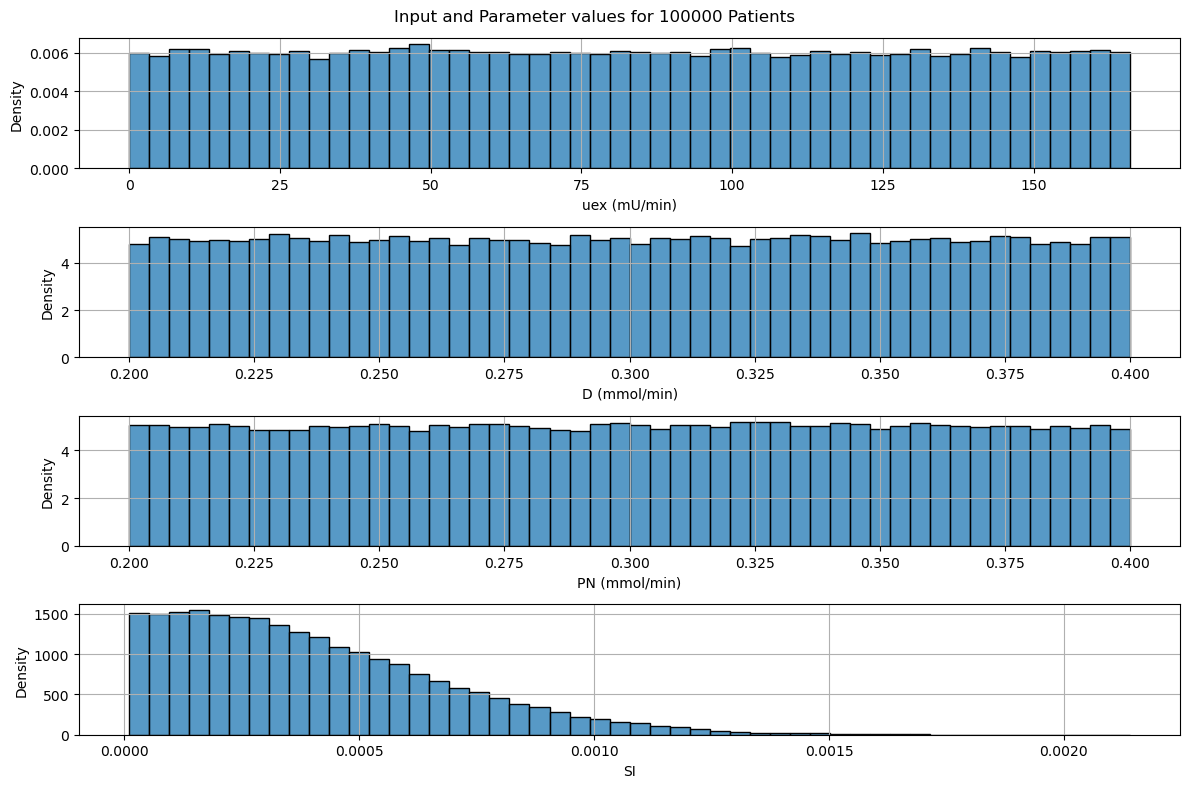

In [4]:
fig, ax = plt.subplots(inputs.shape[0], 1, figsize=(12, 8))
for i in range(inputs.shape[0]):
    sns.histplot(data=inputs[i, :], bins=50, stat="density", ax=ax[i])
    ax[i].set_xlabel(input_labels[i])
    ax[i].grid()
fig.suptitle("Input and Parameter values for 100000 Patients")
fig.tight_layout()

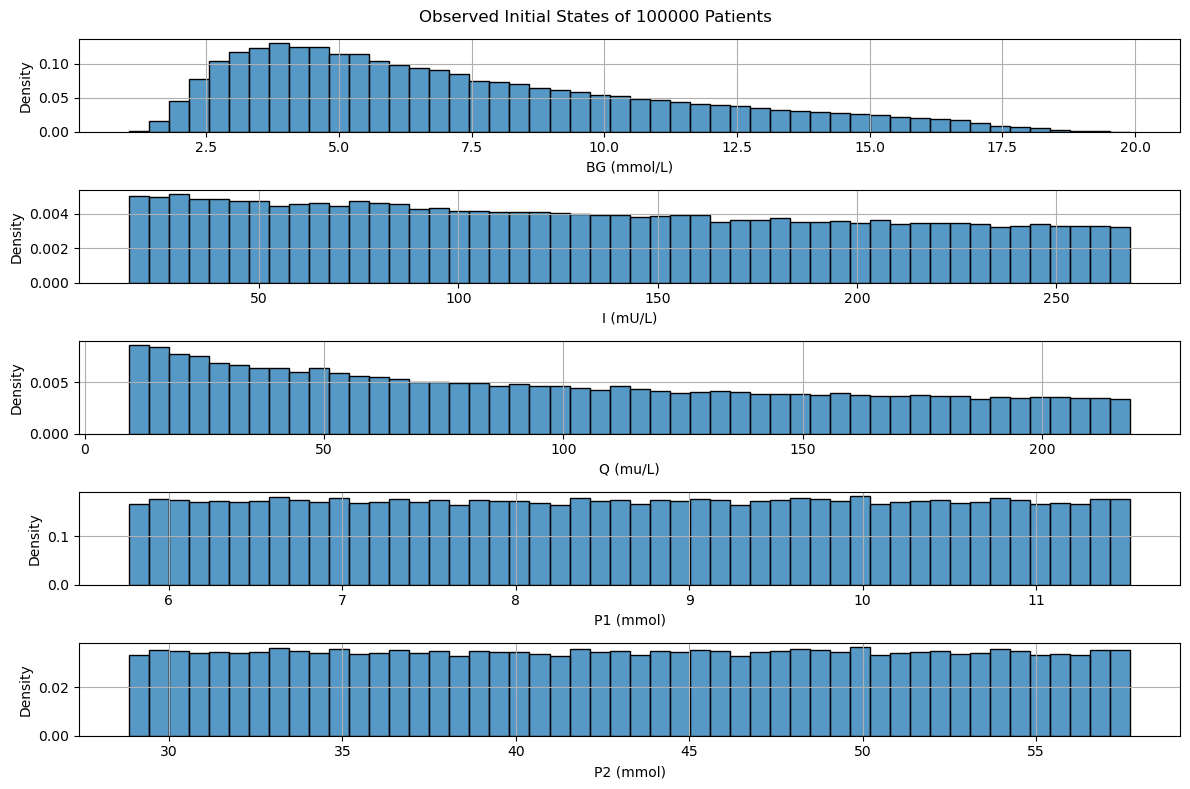

In [5]:
fig, ax = plt.subplots(x0.shape[0], 1, figsize=(12, 8))
for i in range(x0.shape[0]):
    sns.histplot(data=x0[i, :], bins=50, stat="density", ax=ax[i])
    ax[i].set_xlabel(states[i])
    ax[i].grid()
fig.suptitle("Observed Initial States of 100000 Patients")
fig.tight_layout()

In [6]:
print("Mean initial states: ", np.mean(x0, axis=1))
print("Initial Covariance: \n", np.cov(x0, rowvar=True, bias=False))

Mean initial states:  [  7.35697932 133.11498066  98.20321225   8.65661973  43.28309867]
Initial Covariance: 
 [[ 1.52646170e+01 -1.03023806e+02 -8.43116976e+01  4.77157312e-01
   2.38578656e+00]
 [-1.03023806e+02  5.25186254e+03  4.42527492e+03  2.93160307e-01
   1.46580154e+00]
 [-8.43116976e+01  4.42527492e+03  3.73977202e+03  2.61045445e-01
   1.30522722e+00]
 [ 4.77157312e-01  2.93160307e-01  2.61045445e-01  2.77368331e+00
   1.38684165e+01]
 [ 2.38578656e+00  1.46580154e+00  1.30522722e+00  1.38684165e+01
   6.93420827e+01]]


In [7]:
try:
    patient_data = pkl.load(open("../scripts/variables/patient_data_00.pkl", "rb"))
    print("Loaded variable from previous run")
except Exception:
    print("Run 00_Patient_Cohort.py script")

Loaded variable from previous run


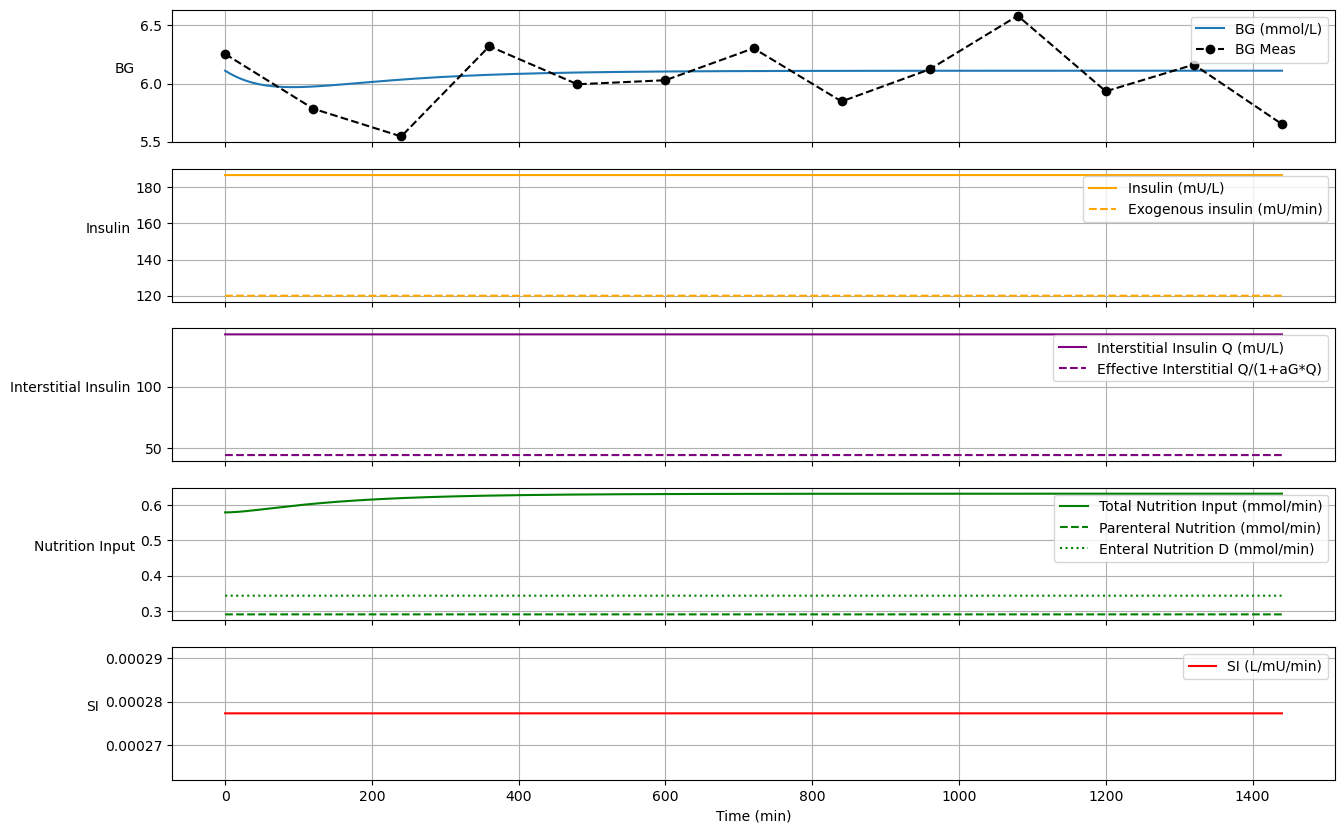

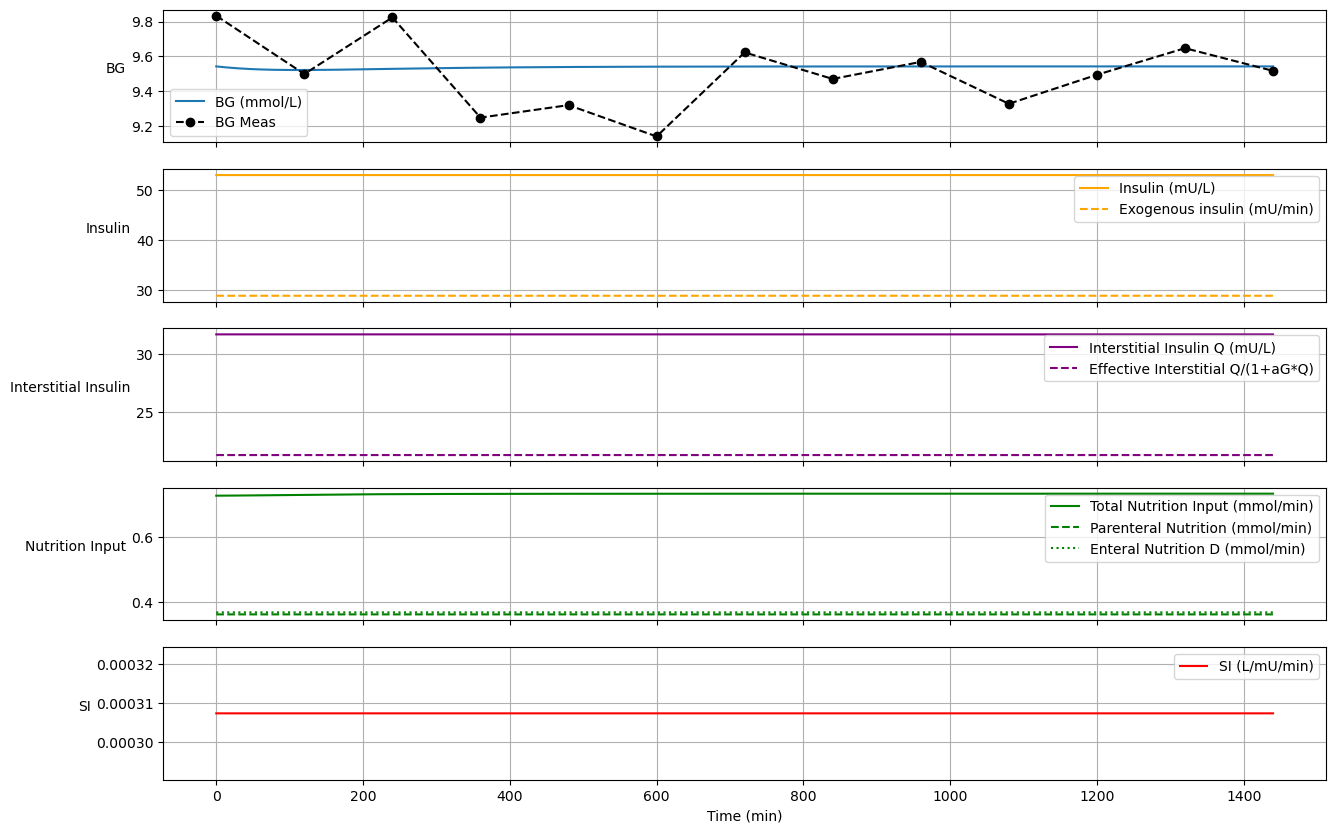

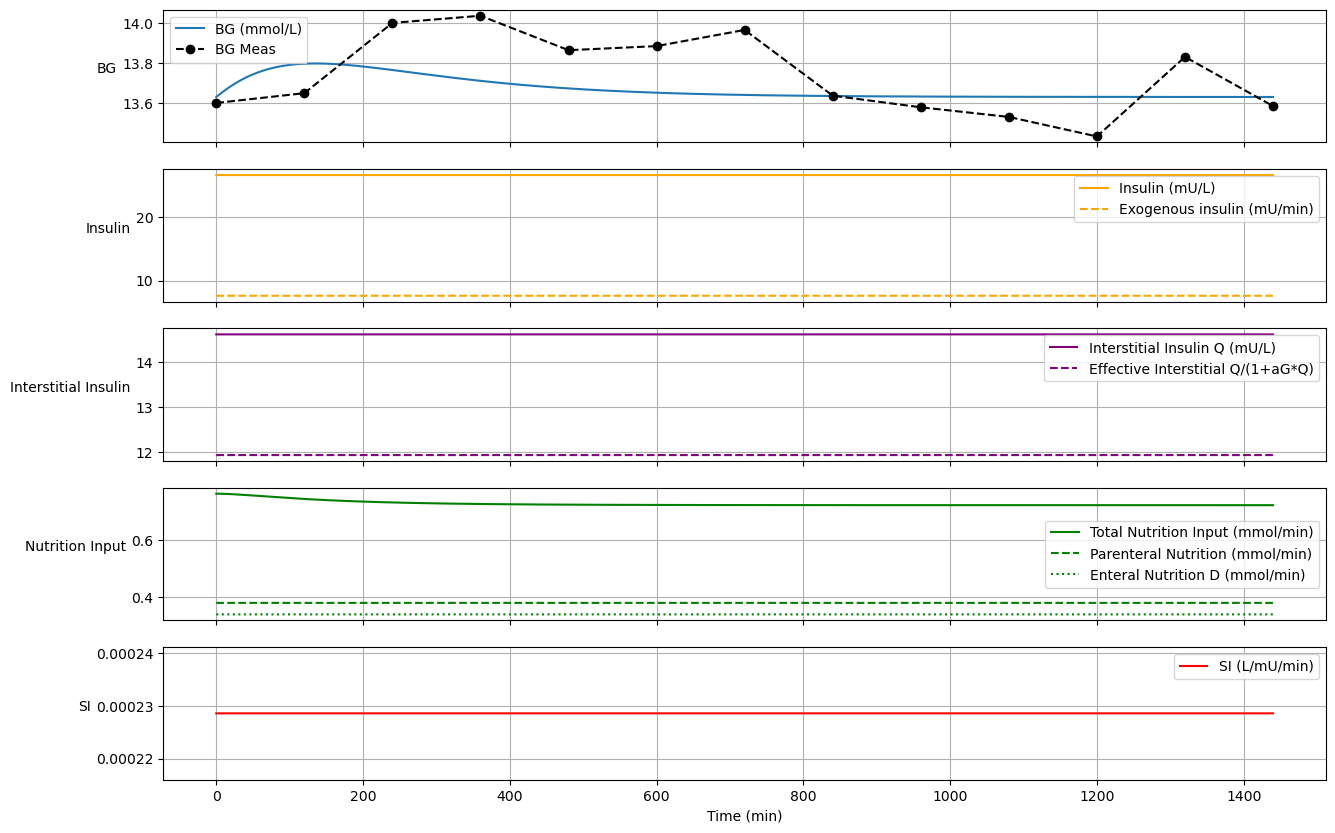

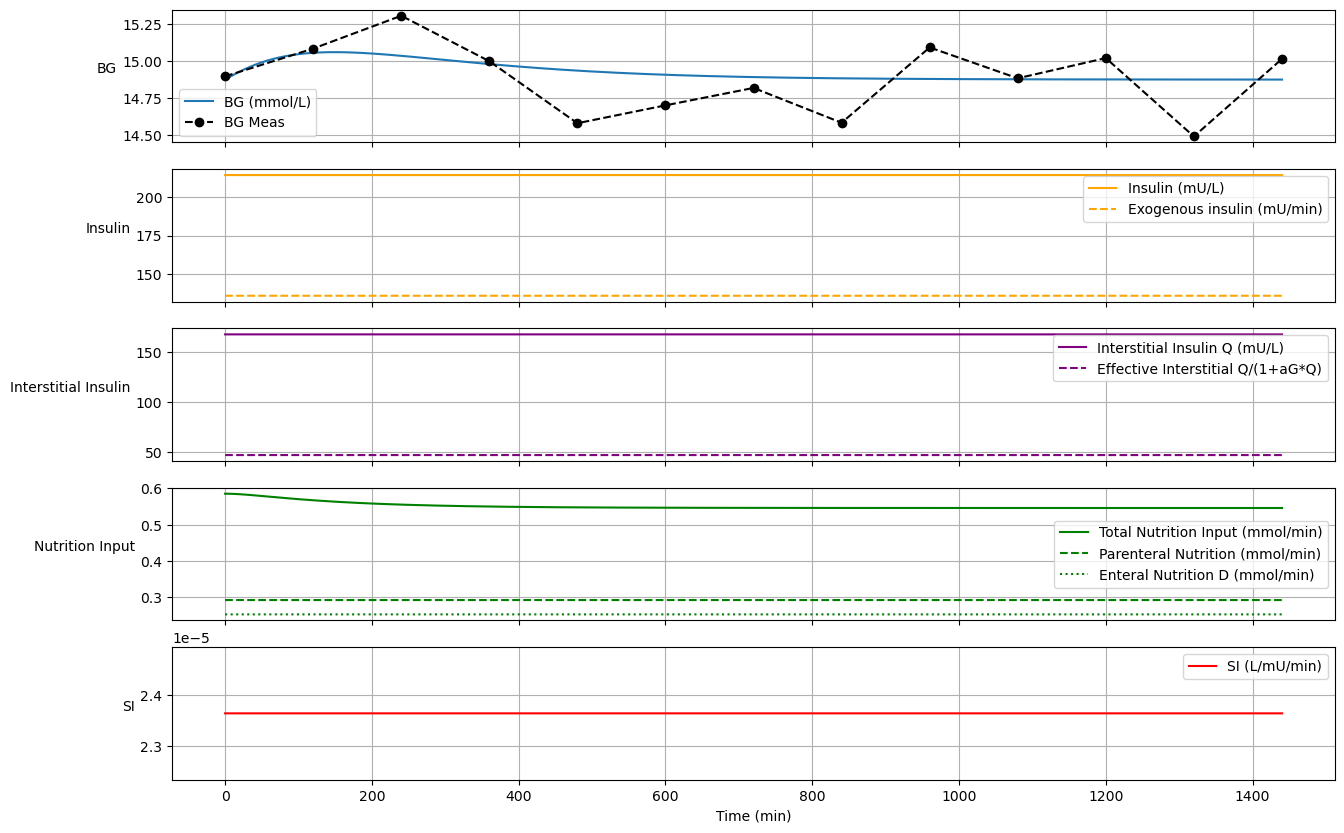

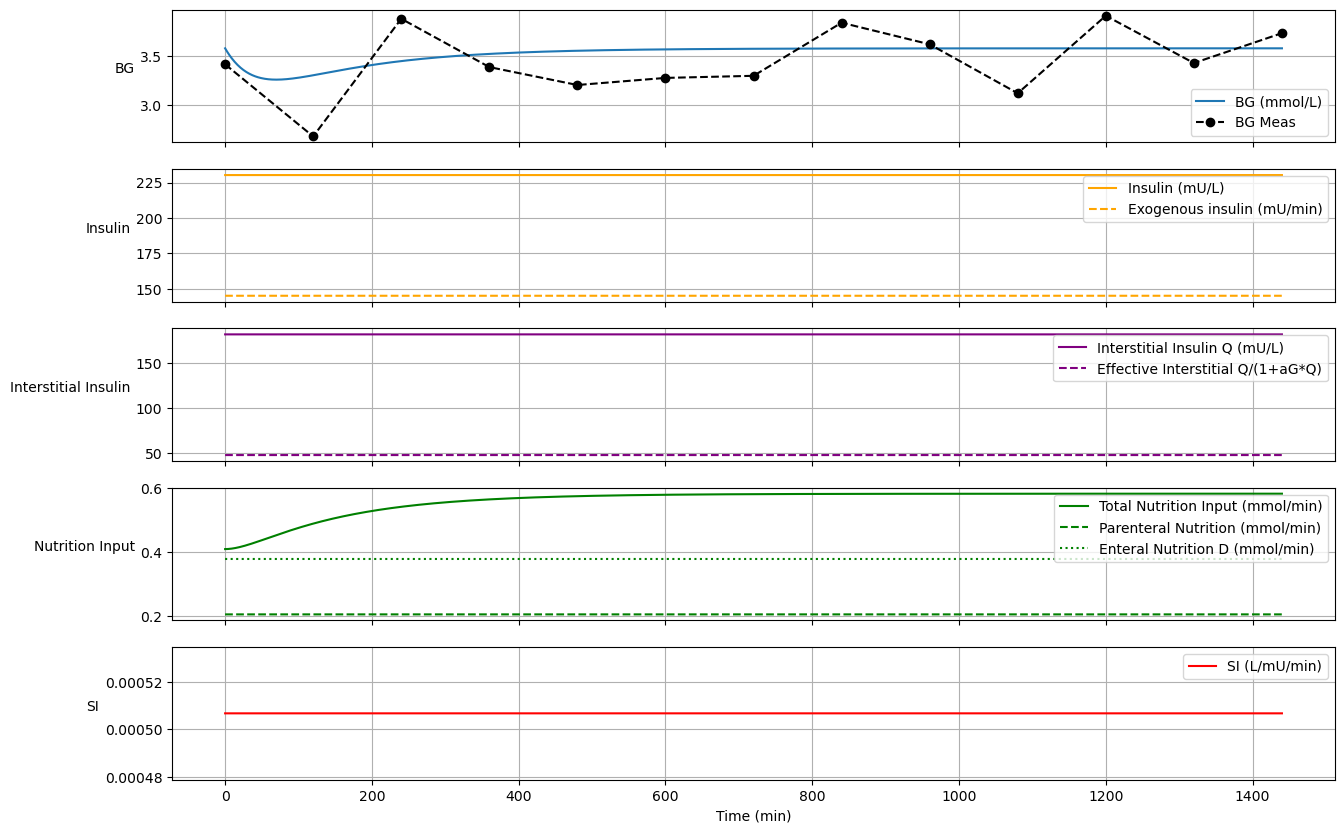

In [8]:
num_patients = len(patient_data)

for i in range(num_patients):
    G = patient_data[i]["BG"]
    G_meas = patient_data[i]["BG_meas"]
    Q = patient_data[i]["Q"]
    I = patient_data[i]["I"]  # noqa: E741
    P1 = patient_data[i]["P1"]
    P2 = patient_data[i]["P2"]
    P = patient_data[i]["P"]
    t = patient_data[i]["t"]
    t_meas = patient_data[i]["t_meas"]
    uex = patient_data[i]["uex"]
    D = patient_data[i]["D"]
    PN = patient_data[i]["PN"]
    SI = patient_data[i]["SI"]
    utils.plot_model(t, t_meas, G, G_meas, Q, I, P1, P2, P, uex, PN, D, SI)
